# 06 Three-Way Comparison: Detection & Explanation

**Pure Faster R-CNN** vs **Neuro-Symbolic (Faster R-CNN + SODT)** vs **Grad-CAM**

This notebook evaluates and compares three aspects:

| Aspect | Models Compared | Metrics |
|--------|----------------|---------|
| **Detection** | Faster R-CNN vs NeSy | mAP, Precision, Recall, F1 |
| **Explanation** | NeSy (SODT) vs GradCAM | Sufficiency, Necessity, Deletion/Insertion AUC, Pointing Game, IoU Heatmap |

Per-image visualizations show:
- **Detection**: 3-column comparison (FRCNN \| NeSy \| Ground Truth)
- **Explanation**: SODT decision tree + heatmap (left) vs GradCAM heatmap (right)

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import time as _time
import torch

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.inference import load_checkpoint_model
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from neurosym.inference import (
    load_neurosymbolic_detector,
    run_neurosymbolic_inference,
    explain_hybrid_detections,
    select_detection_indices,
)
from neurosym.visualization import (
    image_to_array,
    heatmap_to_array,
    draw_numbered_detections,
    draw_neurosymbolic_explanation,
    zoom_axis_to_box,
)
from gradcam.gradcam import GradCAM
from util.config import load_yaml
from util.device import select_device

from torchvision.ops import box_iou as _box_iou
from tqdm import tqdm as _tqdm
from neuro.train import evaluate_model
from neuro.utils import detection_collate_fn
from torch.utils.data import DataLoader
from symbolic.evaluation import (
    evaluate_symbolic_model,
    evaluate_symbolic_spatial_metrics,
)
from gradcam.evaluation import evaluate_gradcam

PROJECT_ROOT = resolve_root()

## 1. Load Models

In [2]:
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)

device = select_device(train_config["device"])
detector_ckpt = PROJECT_ROOT / "checkpoints" / "neuro" / "BESTEST.pt"
symbolic_ckpt = PROJECT_ROOT / "checkpoints" / "symbolic" / "run2.pt"

class_names = tuple(train_config["dataset"]["class_names"])
preprocess = test_preprocess()

# --- Pure Faster R-CNN ---
frcnn_model, _ = load_checkpoint_model(
    detector_ckpt,
    model_config_path=Path("neuro.yaml"),
    train_config_path=Path("neuro_train.yaml"),
    device=str(device),
)
print("✓ Pure Faster R-CNN loaded")

# --- Neuro-Symbolic (SODT) ---
hybrid_model, _ = load_neurosymbolic_detector(
    detector_checkpoint_path=detector_ckpt,
    neuro_config=neuro_config,
    train_config=train_config,
    symbolic_checkpoint_path=symbolic_ckpt,
    device=str(device),
)
print("✓ Neuro-Symbolic (Faster R-CNN + SODT) loaded")

# --- Grad-CAM ---
gradcam = GradCAM(frcnn_model, device=str(device))
print("✓ Grad-CAM initialised (hooked into layer4/c5)")

✓ Pure Faster R-CNN loaded
✓ Neuro-Symbolic (Faster R-CNN + SODT) loaded
✓ Grad-CAM initialised (hooked into layer4/c5)


## 2. Prepare Test Data

In [3]:
test_dataset = PCBDataset(train_config, split_file="test.txt")
test_dataset.add_preprocess(preprocess)

N = 4  # Number of test images to compare
random.seed(42)
sample_indices = random.sample(range(len(test_dataset)), k=min(N, len(test_dataset)))

print(f"Test set size : {len(test_dataset)}")
print(f"Selected indices: {sample_indices}")

Test set size : 500
Selected indices: [327, 57, 12, 379]


## 3. Metrics Computation

Compute **Detection** metrics (FRCNN vs NeSy) and **Explanation** metrics (NeSy vs GradCAM)
on the full test set before visualizing per-image results.

In [4]:
from torchmetrics.detection import MeanAveragePrecision
from neuro.train import count_detection_matches, _confusion_and_per_class

SCORE_THRESHOLD = 0.3

# ── Detection Metrics: FRCNN (batched) ──
test_loader = DataLoader(
    test_dataset,
    batch_size=train_config["dataset"]["batch_size"],
    shuffle=False,
    collate_fn=detection_collate_fn,
)

print("Evaluating Faster R-CNN detection metrics...")
frcnn_det_metrics = evaluate_model(frcnn_model, test_loader, device, train_config)


# ── Single NeSy pass: detection metrics + explanation data ──

tree = hybrid_model.symbolic_tree
evaluation_config = train_config["evaluation"]
num_classes = len(class_names) + 1

# Detection accumulators
nesy_coco = MeanAveragePrecision(
    iou_type="bbox",
    backend="pycocotools",
    class_metrics=evaluation_config["class_metrics"],
)
nesy_paper = MeanAveragePrecision(
    iou_type="bbox",
    backend="pycocotools",
    iou_thresholds=evaluation_config["iou_thresholds"],
)
nesy_conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)
nesy_class_tp = torch.zeros(num_classes, dtype=torch.int64)
nesy_class_fp = torch.zeros(num_classes, dtype=torch.int64)
nesy_class_fn = torch.zeros(num_classes, dtype=torch.int64)
nesy_tp = nesy_fp = nesy_fn = 0
nesy_forward_times = []

# Explanation accumulators
all_features = []
all_grids = []
all_proposal_boxes = []
all_matched_gt_boxes = []
all_has_matched = []
all_gt_iou = []
all_images = []
all_targets = []

print("Running single NeSy pass (detection + explanation)...")
for batch_images, batch_targets in _tqdm(test_loader, desc="NeSy combined eval"):
    t0 = _time.perf_counter()
    with torch.inference_mode():
        outputs = hybrid_model([img.to(device) for img in batch_images])
    nesy_forward_times.append(_time.perf_counter() - t0)

    for det, target in zip(outputs, batch_targets):
        # ── Detection metrics ──
        prediction = {
            "boxes": det["boxes"].detach().cpu(),
            "scores": det["scores"].detach().cpu(),
            "labels": det["labels"].detach().cpu(),
        }
        ground_truth = {
            "boxes": target["boxes"].detach().cpu(),
            "labels": target["labels"].detach().cpu(),
        }
        nesy_coco.update([prediction], [ground_truth])
        nesy_paper.update([prediction], [ground_truth])

        tp, fp, fn = count_detection_matches(
            prediction,
            ground_truth,
            iou_threshold=evaluation_config["precision_iou"],
            score_threshold=evaluation_config["precision_score_threshold"],
        )
        nesy_tp += tp
        nesy_fp += fp
        nesy_fn += fn
        pc = _confusion_and_per_class(
            prediction,
            ground_truth,
            iou_threshold=evaluation_config["precision_iou"],
            score_threshold=evaluation_config["precision_score_threshold"],
            num_classes=len(class_names),
        )
        nesy_conf_matrix += pc["confusion"]
        nesy_class_tp += pc["class_tp"]
        nesy_class_fp += pc["class_fp"]
        nesy_class_fn += pc["class_fn"]

        # ── Explanation data ──
        n_det = det["boxes"].shape[0]
        all_images.append(target.get("_image_tensor", None))  # placeholder
        all_targets.append(target)

        if n_det == 0:
            continue
        pooled = det["pooled_features"].detach().cpu()
        proposals = det["proposal_boxes"].detach().cpu()
        gt_boxes = target["boxes"]

        all_features.append(pooled.flatten(start_dim=1).numpy())
        all_grids.append(pooled.numpy())
        all_proposal_boxes.append(proposals)

        if gt_boxes.numel() > 0:
            overlaps = _box_iou(proposals, gt_boxes)
            matched_iou, matched_idx = overlaps.max(dim=1)
            matched_boxes = gt_boxes[matched_idx]
            has_match = matched_iou > 0
            all_matched_gt_boxes.append(matched_boxes)
            all_has_matched.append(has_match)
            all_gt_iou.append(matched_iou)
        else:
            all_matched_gt_boxes.append(torch.zeros((n_det, 4)))
            all_has_matched.append(torch.zeros(n_det, dtype=torch.bool))
            all_gt_iou.append(torch.zeros(n_det))

# ── Build NeSy detection metrics dict ──
nesy_coco_out = nesy_coco.compute()
nesy_paper_out = nesy_paper.compute()
nesy_precision = nesy_tp / max(nesy_tp + nesy_fp, 1)
nesy_recall = nesy_tp / max(nesy_tp + nesy_fn, 1)
all_class_names = ["__background__", *class_names]

nesy_det_metrics = {
    "mAP@0.5:0.95": nesy_coco_out["map"].item(),
    "mAP@0.5": nesy_coco_out["map_50"].item(),
    "AP75": nesy_coco_out["map_75"].item(),
    "AP@50:5:85": nesy_paper_out["map"].item(),
    "precision": nesy_precision,
    "recall": nesy_recall,
    "mar_100": nesy_coco_out["mar_100"].item(),
    "f1_score": 2
    * nesy_precision
    * nesy_recall
    / max(nesy_precision + nesy_recall, 1e-10),
    "inference_time_ms": float(np.mean(nesy_forward_times)) * 1000
    if nesy_forward_times
    else 0.0,
    "confusion_matrix": nesy_conf_matrix.tolist(),
    "confusion_matrix_labels": all_class_names,
}

print(
    f"FRCNN  mAP@0.5:0.95 = {frcnn_det_metrics['mAP@0.5:0.95']:.4f}  |  NeSy  mAP@0.5:0.95 = {nesy_det_metrics['mAP@0.5:0.95']:.4f}"
)
print(
    f"FRCNN  precision    = {frcnn_det_metrics['precision']:.4f}  |  NeSy  precision    = {nesy_det_metrics['precision']:.4f}"
)
print(
    f"FRCNN  recall       = {frcnn_det_metrics['recall']:.4f}  |  NeSy  recall       = {nesy_det_metrics['recall']:.4f}"
)

# ── NeSy explanation metrics (from collected data) ──
feature_matrix = np.concatenate(all_features, axis=0).astype(np.float32)
feature_grids = torch.from_numpy(np.concatenate(all_grids, axis=0))
all_proposals_t = torch.cat(all_proposal_boxes, dim=0)
all_matched_gt_t = torch.cat(all_matched_gt_boxes, dim=0)
all_has_matched_t = torch.cat(all_has_matched, dim=0)
all_gt_iou_t = torch.cat(all_gt_iou, dim=0)

nesy_pred = tree.predict_proba(feature_matrix).argmax(axis=1)
nesy_expl_metrics = evaluate_symbolic_model(
    tree, feature_matrix, nesy_pred, class_names
)
nesy_spatial = evaluate_symbolic_spatial_metrics(
    tree,
    feature_grids,
    all_proposals_t,
    all_matched_gt_t,
    all_has_matched_t,
    all_gt_iou_t,
    heatmap_mode="leaf_only",
    min_proposal_iou=0.5,
)
nesy_expl_metrics.update(nesy_spatial)

# ── GradCAM explanation metrics (needs images; collect separately) ──
print("Computing GradCAM explanation metrics...")
gradcam_images = []
gradcam_targets = []
for i in range(len(test_dataset)):
    image, target = test_dataset[i]
    gradcam_images.append(image)
    gradcam_targets.append(target)

gradcam_expl_metrics = evaluate_gradcam(
    model=frcnn_model,
    gradcam=gradcam,
    images=gradcam_images,
    targets=gradcam_targets,
    class_names=class_names,
    score_threshold=SCORE_THRESHOLD,
    num_images=500,
)

print(f"{'Metric':<35} {'NeSy (SODT)':>12} {'GradCAM':>12}")
print("-" * 62)
for key in [
    "sufficiency_prediction_preservation",
    "necessity_prediction_flip_rate",
    "deletion_auc",
    "insertion_auc",
    "pointing_score",
    "box_grounded_roi_overlap",
]:
    nv = nesy_expl_metrics.get(key, float("nan"))
    gv = gradcam_expl_metrics.get(key, float("nan"))
    print(f"{key:<35} {nv:>12.4f} {gv:>12.4f}")
# ── Inference Time Summary ──
print(f"\n{'─' * 60}")
print("Average Inference Time per Image (metrics evaluation)")
print(f"{'─' * 60}")
print(
    f"  Faster R-CNN : {frcnn_det_metrics['inference_time_ms']:.1f} ms  (batched avg)"
)
print(
    f"  NeSy (FRCNN+SODT) : {nesy_det_metrics['inference_time_ms']:.1f} ms  (batched avg)"
)
print(
    f"  GradCAM (FRCNN+GradCAM) : {gradcam_expl_metrics['inference_time_ms_avg']:.1f} ms  (avg)"
)
print(
    f"    GradCAM min: {gradcam_expl_metrics['inference_time_ms_min']:.1f} ms  max: {gradcam_expl_metrics['inference_time_ms_max']:.1f} ms"
)

Evaluating Faster R-CNN detection metrics...


Running single NeSy pass (detection + explanation)...


NeSy combined eval: 100%|██████████| 500/500 [00:27<00:00, 17.99it/s]


FRCNN  mAP@0.5:0.95 = 0.7641  |  NeSy  mAP@0.5:0.95 = 0.6677
FRCNN  precision    = 0.8958  |  NeSy  precision    = 0.8226
FRCNN  recall       = 0.9803  |  NeSy  recall       = 0.9850


Spatial grounding: 100%|██████████| 13637/13637 [00:01<00:00, 12913.90it/s]


Computing GradCAM explanation metrics...


Grad-CAM collection: 100%|██████████| 500/500 [02:26<00:00,  3.41it/s]


Metric                               NeSy (SODT)      GradCAM
--------------------------------------------------------------
sufficiency_prediction_preservation       1.0000       0.9505
necessity_prediction_flip_rate            1.0000       0.0515
deletion_auc                              0.2975       0.6807
insertion_auc                             0.7555       0.6825
pointing_score                            0.9553       0.9854
box_grounded_roi_overlap                  0.8965       0.9863

────────────────────────────────────────────────────────────
Average Inference Time per Image (metrics evaluation)
────────────────────────────────────────────────────────────
  Faster R-CNN : 44.2 ms  (batched avg)
  NeSy (FRCNN+SODT) : 51.6 ms  (batched avg)
  GradCAM (FRCNN+GradCAM) : 286.2 ms  (avg)
    GradCAM min: 111.1 ms  max: 1189.6 ms


## 4. Metrics Visualization

Side-by-side bar charts comparing detection and explanation metrics.

/tmp/ipykernel_35912/3013016909.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


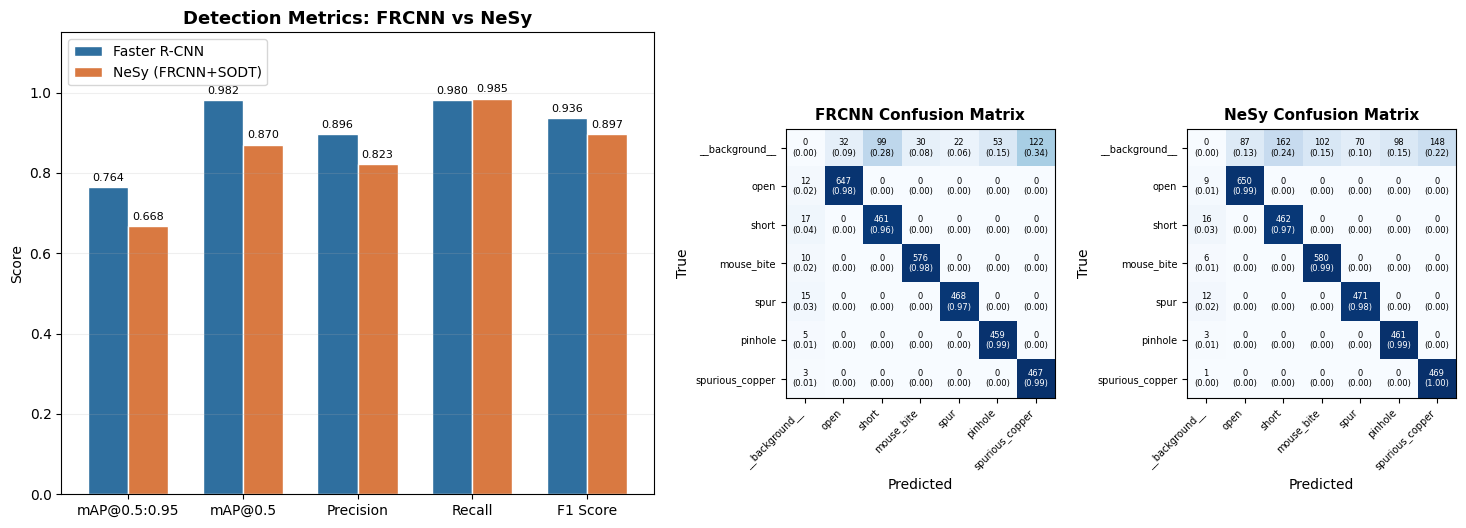

In [5]:
# ── Detection Metrics Bar Chart + Confusion Matrix ──
det_keys = ["mAP@0.5:0.95", "mAP@0.5", "precision", "recall", "f1_score"]
det_labels = ["mAP@0.5:0.95", "mAP@0.5", "Precision", "Recall", "F1 Score"]
frcnn_vals = [frcnn_det_metrics[k] for k in det_keys]
nesy_vals = [nesy_det_metrics[k] for k in det_keys]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 1, 1], wspace=0.35)

# Panel 1: Bar chart
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(det_labels))
w = 0.35
b1 = ax.bar(
    x - w / 2, frcnn_vals, w, label="Faster R-CNN", color="#2F6F9F", edgecolor="white"
)
b2 = ax.bar(
    x + w / 2,
    nesy_vals,
    w,
    label="NeSy (FRCNN+SODT)",
    color="#D97941",
    edgecolor="white",
)
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(det_labels, fontsize=10)
ax.set_ylabel("Score")
ax.set_title("Detection Metrics: FRCNN vs NeSy", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.2)


# Panel 2: FRCNN confusion matrix
def _plot_confusion_matrix(ax, metrics_dict, title):
    cm = np.array(metrics_dict["confusion_matrix"])
    labels = metrics_dict["confusion_matrix_labels"]
    # Include background row/col (index 0)
    cm_defect = cm
    defect_labels = labels
    # Normalize per row (recall-normalized)
    row_sums = cm_defect.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm_defect / row_sums, 0.0)

    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(defect_labels)))
    ax.set_yticks(range(len(defect_labels)))
    ax.set_xticklabels(defect_labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(defect_labels, fontsize=7)
    for i in range(cm_defect.shape[0]):
        for j in range(cm_defect.shape[1]):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(
                j,
                i,
                f"{cm_defect[i, j]}\n({cm_norm[i, j]:.2f})",
                ha="center",
                va="center",
                fontsize=6,
                color=color,
            )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")


ax_frcnn_cm = fig.add_subplot(gs[0, 1])
_plot_confusion_matrix(ax_frcnn_cm, frcnn_det_metrics, "FRCNN Confusion Matrix")

# Panel 3: NeSy confusion matrix
ax_nesy_cm = fig.add_subplot(gs[0, 2])
_plot_confusion_matrix(ax_nesy_cm, nesy_det_metrics, "NeSy Confusion Matrix")

plt.tight_layout()
plt.show()

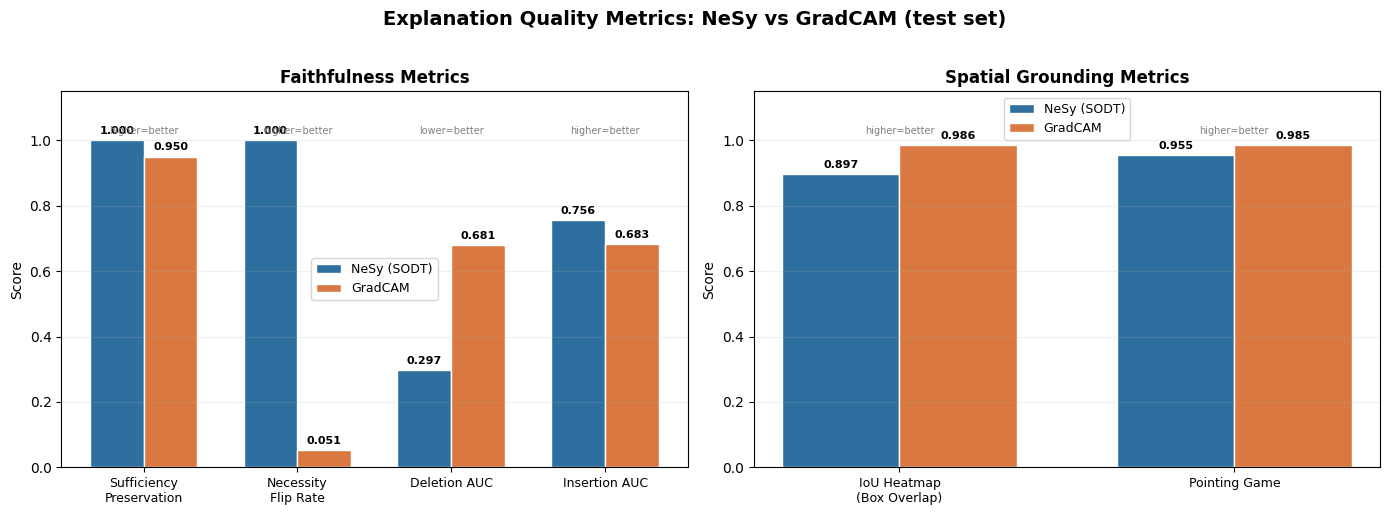

In [6]:
# ── Explanation Metrics Bar Chart: NeSy vs GradCAM ──
faith_labels = [
    "Sufficiency\nPreservation",
    "Necessity\nFlip Rate",
    "Deletion AUC",
    "Insertion AUC",
]
faith_keys = [
    "sufficiency_prediction_preservation",
    "necessity_prediction_flip_rate",
    "deletion_auc",
    "insertion_auc",
]
nesy_faith = [nesy_expl_metrics.get(k, 0.0) for k in faith_keys]
gcam_faith = [gradcam_expl_metrics.get(k, 0.0) for k in faith_keys]

spatial_labels = ["IoU Heatmap\n(Box Overlap)", "Pointing Game"]
spatial_keys = ["box_grounded_roi_overlap", "pointing_score"]
nesy_spatial_vals = [nesy_expl_metrics.get(k, 0.0) for k in spatial_keys]
gcam_spatial_vals = [gradcam_expl_metrics.get(k, 0.0) for k in spatial_keys]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Explanation Quality Metrics: NeSy vs GradCAM (test set)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

# Panel 1: Faithfulness
ax = axes[0]
x = np.arange(len(faith_labels))
w = 0.35
b1 = ax.bar(
    x - w / 2, nesy_faith, w, label="NeSy (SODT)", color="#2F6F9F", edgecolor="white"
)
b2 = ax.bar(
    x + w / 2, gcam_faith, w, label="GradCAM", color="#D97941", edgecolor="white"
)
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8, fontweight="bold")
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(faith_labels, fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Faithfulness Metrics", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
ann = ["higher=better", "higher=better", "lower=better", "higher=better"]
for i, a in enumerate(ann):
    ax.annotate(a, (i, 1.02), fontsize=7, color="gray", ha="center")
ax.grid(axis="y", alpha=0.2)

# Panel 2: Spatial
ax = axes[1]
x = np.arange(len(spatial_labels))
w = 0.35
b1 = ax.bar(
    x - w / 2,
    nesy_spatial_vals,
    w,
    label="NeSy (SODT)",
    color="#2F6F9F",
    edgecolor="white",
)
b2 = ax.bar(
    x + w / 2, gcam_spatial_vals, w, label="GradCAM", color="#D97941", edgecolor="white"
)
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8, fontweight="bold")
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(spatial_labels, fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Spatial Grounding Metrics", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
for i in range(len(spatial_labels)):
    ax.annotate("higher=better", (i, 1.02), fontsize=7, color="gray", ha="center")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Per-Image Comparison

For each selected test image:
1. **Detection**: 3-column comparison — Faster R-CNN | NeSy (FRCNN+SODT) | Ground Truth
2. **Explanation**: Interactive selector — SODT decision tree + heatmap (left) vs GradCAM heatmap (right)


Test Image #327  (FRCNN: 41.8 | NeSy: 52.9 | GradCAM: 215.5 | Total: 310.2 ms)

── Detection ──


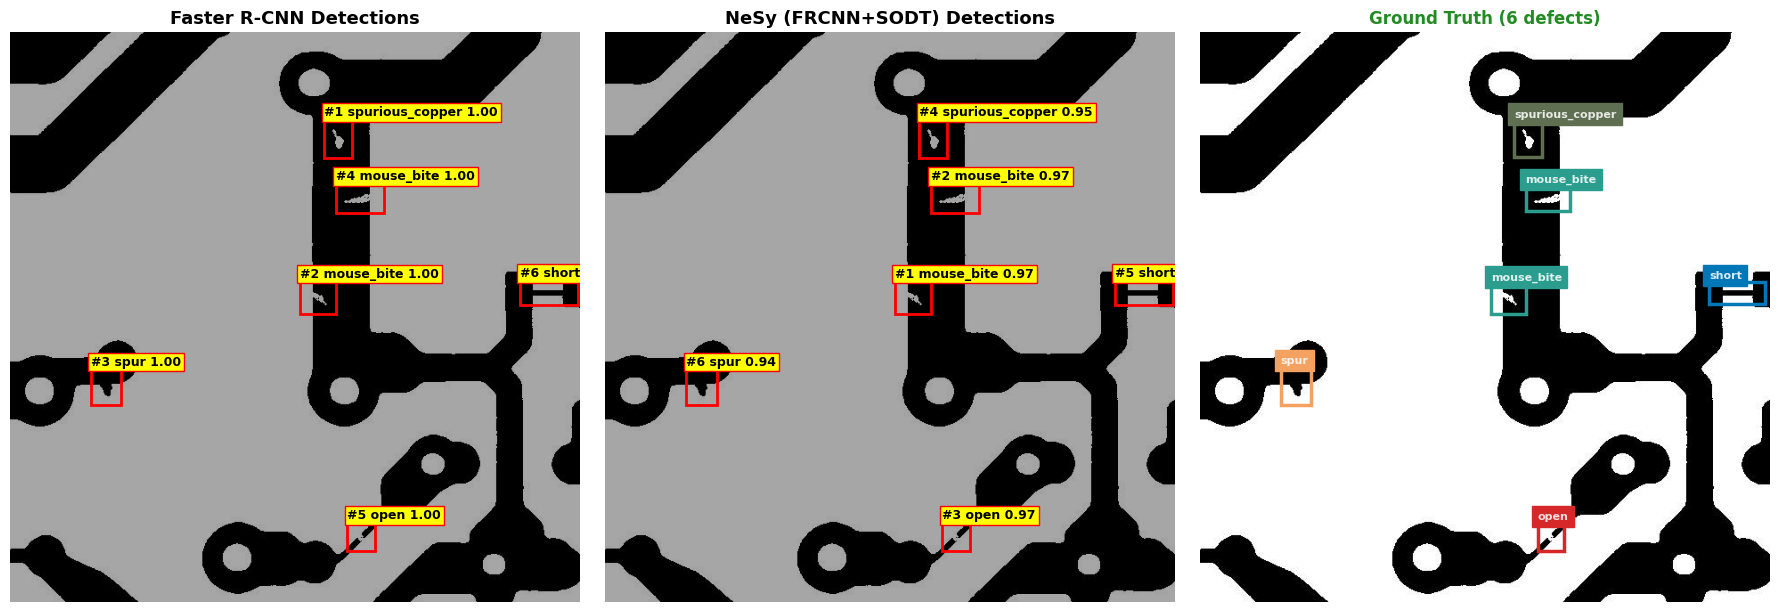

── Explanation ──


Output()


Test Image #57  (FRCNN: 37.8 | NeSy: 52.1 | GradCAM: 173.1 | Total: 263.1 ms)

── Detection ──


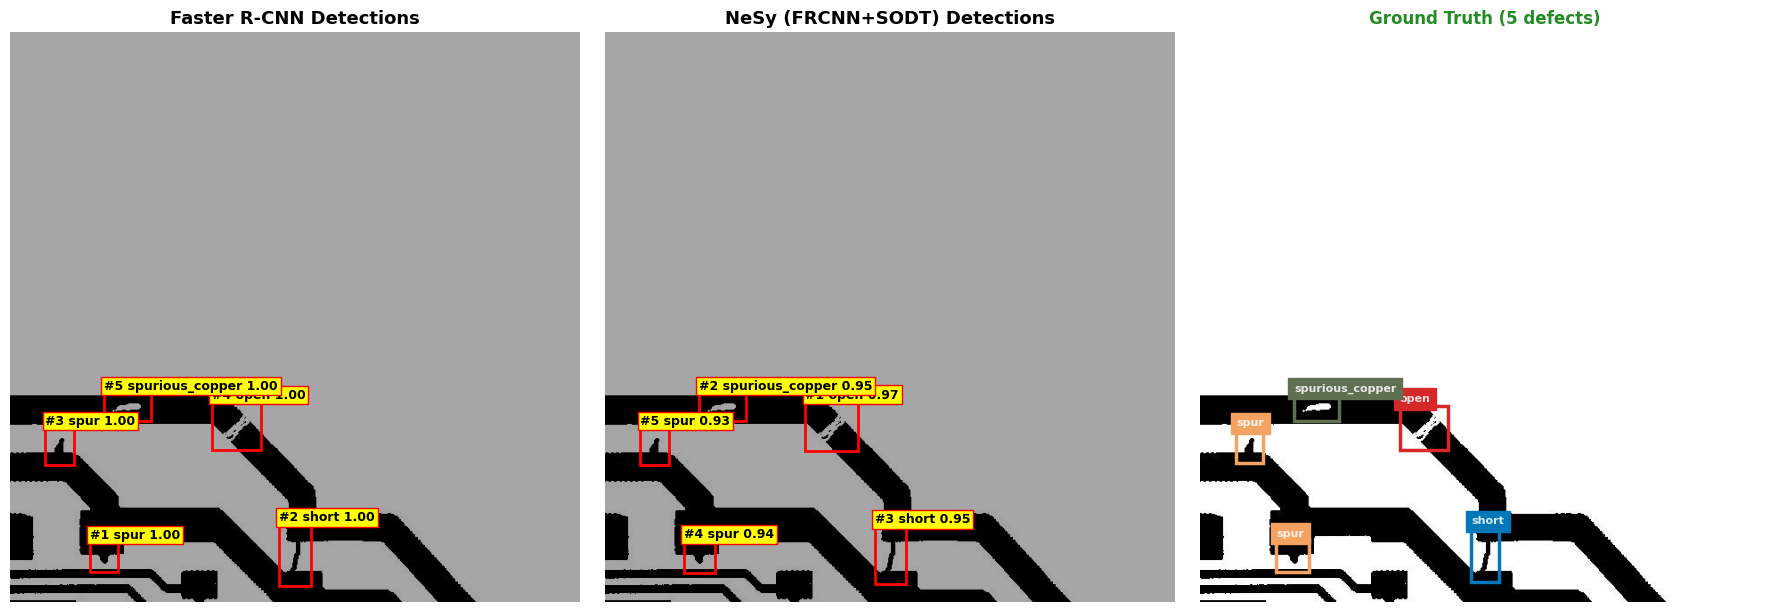

── Explanation ──


Output()


Test Image #12  (FRCNN: 49.0 | NeSy: 58.2 | GradCAM: 203.6 | Total: 310.9 ms)

── Detection ──


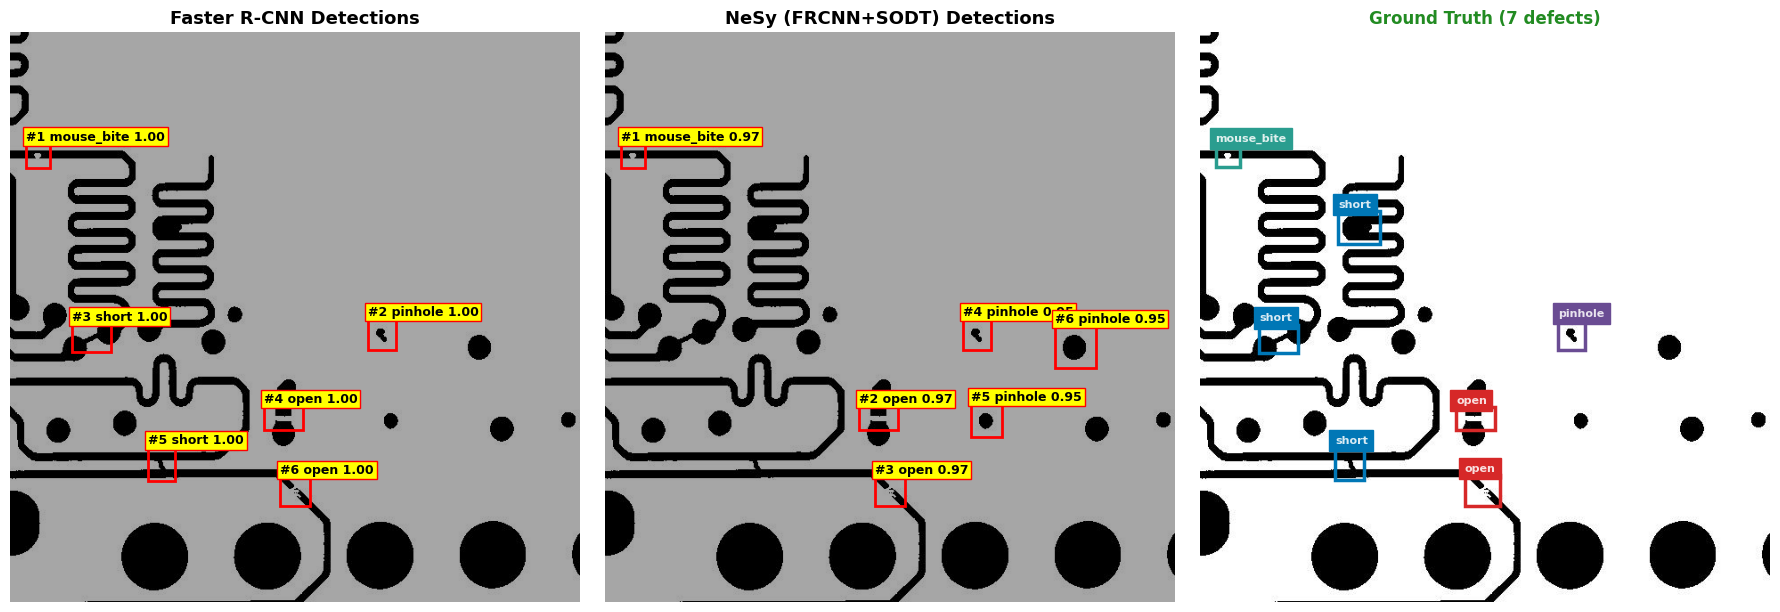

── Explanation ──


Output()


Test Image #379  (FRCNN: 40.3 | NeSy: 54.1 | GradCAM: 205.3 | Total: 299.7 ms)

── Detection ──


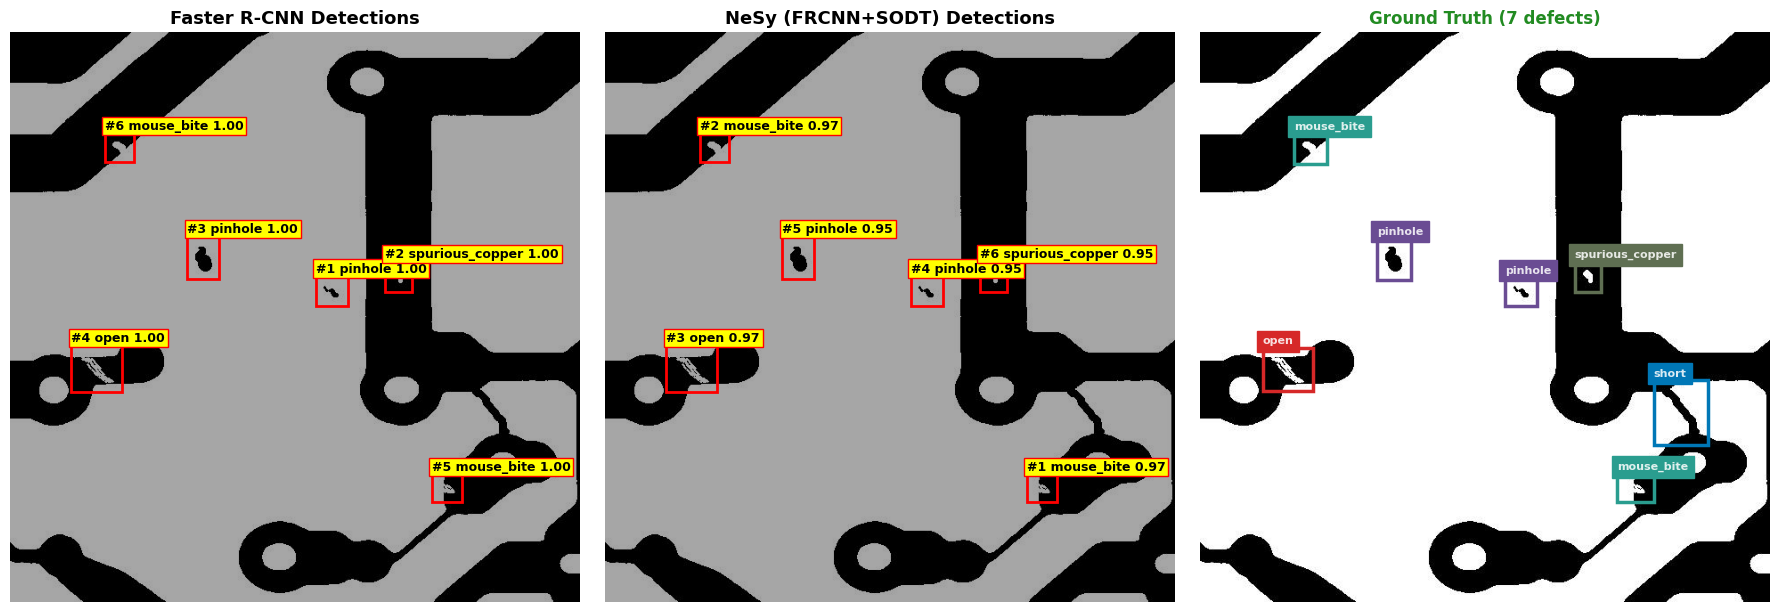

── Explanation ──


Output()


────────────────────────────────────────────────────────────────────────────────
Per-Image Inference Time (ms)
────────────────────────────────────────────────────────────────────────────────
  Faster R-CNN               avg: 42.2 ms  min: 37.8 ms  max: 49.0 ms
  NeSy (FRCNN+SODT)          avg: 54.4 ms  min: 52.1 ms  max: 58.2 ms
  GradCAM (FRCNN+GradCAM)    avg: 199.4 ms  min: 173.1 ms  max: 215.5 ms
  TOTAL                      avg: 296.0 ms  min: 263.1 ms  max: 310.9 ms
────────────────────────────────────────────────────────────────────────────────
Image         FRCNN     NeSy  GradCAM    Total
  #327          41.8     52.9    215.5    310.2
  #57           37.8     52.1    173.1    263.1
  #12           49.0     58.2    203.6    310.9
  #379          40.3     54.1    205.3    299.7


In [7]:
MAX_DETECTIONS = 6

frcnn_times = []
nesy_times = []
gradcam_times = []


def _draw_gradcam_panel_in_axis(ax, image_tensor, gcam_result, class_names):
    from neurosym.heatmap import project_heatmap_to_image

    img = image_to_array(image_tensor)
    ax.imshow(img)

    dimmer = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.float32)
    dimmer[..., 3] = 0.4
    ax.imshow(dimmer)

    heatmap_tensor = gcam_result["heatmap"]
    box = gcam_result["box"]
    image_shape = tuple(image_tensor.shape[-2:])

    projected = project_heatmap_to_image(heatmap_tensor, box, image_shape)

    rgba = heatmap_to_array(projected)
    ax.imshow(rgba)

    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="cyan",
            facecolor="none",
        )
    )

    zoom_axis_to_box(ax, box, image_shape)
    label = gcam_result["label"]
    score = gcam_result["score"]
    name = class_names[label - 1] if 0 < label <= len(class_names) else f"cls{label}"
    ax.set_title(
        f"Grad-CAM Focus\n{name} {score:.2f}",
        fontsize=10,
        fontweight="bold",
        color="#c62828",
    )
    ax.axis("off")


def _draw_gt_panel(ax, image_tensor, target, class_names):
    """Draw ground-truth annotations on the image."""
    img = image_to_array(image_tensor)
    ax.imshow(img)
    gt_boxes = target["boxes"]
    gt_labels = target["labels"]
    palette = ["#d62828", "#0077b6", "#2a9d8f", "#f4a261", "#6a4c93", "#5f6f52"]
    for i in range(gt_boxes.shape[0]):
        x1, y1, x2, y2 = gt_boxes[i].tolist()
        lbl = int(gt_labels[i])
        name = class_names[lbl - 1] if 0 < lbl <= len(class_names) else f"cls{lbl}"
        color = palette[(lbl - 1) % len(palette)]
        ax.add_patch(
            patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2.5,
                edgecolor=color,
                facecolor="none",
            )
        )
        ax.text(
            x1,
            max(y1 - 4, 10),
            name,
            fontsize=8,
            fontweight="bold",
            color="white",
            backgroundcolor=color,
            alpha=0.85,
        )
    ax.set_title(
        f"Ground Truth ({gt_boxes.shape[0]} defects)",
        fontsize=12,
        fontweight="bold",
        color="#228B22",
    )
    ax.axis("off")


for sample_idx in sample_indices:
    image_tensor, target = test_dataset[sample_idx]
    image_shape = tuple(image_tensor.shape[-2:])

    # ---------- (A) Pure Faster R-CNN inference ----------
    t0 = _time.perf_counter()
    with torch.inference_mode():
        frcnn_preds = frcnn_model([image_tensor.to(device)])
        frcnn_det = {k: v.detach().cpu() for k, v in frcnn_preds[0].items()}
    t_frcnn = (_time.perf_counter() - t0) * 1000
    frcnn_times.append(t_frcnn)

    # ---------- (B) Neuro-Symbolic inference + explanation ----------
    t0 = _time.perf_counter()
    with torch.inference_mode():
        hybrid_preds = run_neurosymbolic_inference(
            hybrid_model, [image_tensor.to(device)]
        )
        hybrid_det = hybrid_preds[0]
    t_nesy = (_time.perf_counter() - t0) * 1000
    nesy_times.append(t_nesy)

    sodt_indices = select_detection_indices(
        hybrid_det,
        score_threshold=SCORE_THRESHOLD,
        max_detections=MAX_DETECTIONS,
    )

    sodt_explanations = explain_hybrid_detections(
        hybrid_model,
        hybrid_det,
        image_shape=image_shape,
        detection_indices=sodt_indices,
        mode="local_instance_evidence_map",
    )

    # ---------- (C) Grad-CAM ----------
    t0 = _time.perf_counter()
    boxes_selected = hybrid_det["boxes"][sodt_indices]
    labels_selected = hybrid_det["labels"][sodt_indices]
    scores_selected = hybrid_det["scores"][sodt_indices]

    if len(sodt_indices) > 0:
        gcam_heatmaps = gradcam.generate(
            image_tensor,
            boxes_selected.to(device),
            labels_selected.to(device),
            output_size=(7, 7),
        )
        gcam_results = [
            {
                "box": boxes_selected[i].detach().cpu(),
                "label": int(labels_selected[i]),
                "score": float(scores_selected[i]),
                "heatmap": gcam_heatmaps[i],
            }
            for i in range(len(sodt_indices))
        ]
    else:
        gcam_results = []
    t_gradcam = (_time.perf_counter() - t0) * 1000
    gradcam_times.append(t_gradcam)

    total_ms = t_frcnn + t_nesy + t_gradcam
    print(f"\n{'=' * 100}")
    print(
        f"Test Image #{sample_idx}  (FRCNN: {t_frcnn:.1f} | NeSy: {t_nesy:.1f} | GradCAM: {t_gradcam:.1f} | Total: {total_ms:.1f} ms)"
    )
    print(f"{'=' * 100}\n")

    # ═══════════════════════════════════════════════════════════
    # DETECTION SECTION: FRCNN | NeSy | Ground Truth
    # ═══════════════════════════════════════════════════════════
    print("── Detection ──")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    draw_numbered_detections(
        axes[0], image_tensor, frcnn_det, sodt_indices, class_names
    )
    axes[0].set_title("Faster R-CNN Detections", fontsize=13, fontweight="bold")

    draw_numbered_detections(
        axes[1], image_tensor, hybrid_det, sodt_indices, class_names
    )
    axes[1].set_title("NeSy (FRCNN+SODT) Detections", fontsize=13, fontweight="bold")

    _draw_gt_panel(axes[2], image_tensor, target, class_names)

    plt.tight_layout()
    plt.show()

    # ═══════════════════════════════════════════════════════════
    # EXPLANATION SECTION: SODT Tree+Heatmap | GradCAM Heatmap
    # ═══════════════════════════════════════════════════════════
    print("── Explanation ──")
    if len(sodt_indices) == 0:
        print("No detections above threshold.")
        continue

    out = widgets.Output()

    def make_btn(
        btn_num,
        det_idx,
        expl,
        gcam_res,
        tnsr=image_tensor,
        hyb=hybrid_det,
        out_w=out,
    ):
        label_name = class_names[expl["label"] - 1]
        score = expl["score"]
        btn = widgets.Button(
            description=f"#{btn_num} {label_name} {score:.2f}",
            layout=widgets.Layout(width="180px"),
        )

        def on_click(_):
            with out_w:
                clear_output(wait=True)

                def gcam_panel(ax):
                    _draw_gradcam_panel_in_axis(ax, tnsr, gcam_res, class_names)

                draw_neurosymbolic_explanation(
                    tnsr,
                    hyb,
                    det_idx,
                    expl,
                    class_names,
                    hybrid_model.symbolic_tree,
                    selected_number=btn_num,
                    extra_panel_func=gcam_panel,
                )

        btn.on_click(on_click)
        return btn

    buttons = []
    for btn_num, (det_idx, expl, gcam_res) in enumerate(
        zip(sodt_indices, sodt_explanations, gcam_results), 1
    ):
        buttons.append(make_btn(btn_num, det_idx, expl, gcam_res))

    display(widgets.HBox(buttons))
    display(out)

# ── Inference Time Summary ──
if frcnn_times:

    def _print_stats(name, times):
        arr = np.array(times)
        print(
            f"  {name:<25s}  avg: {arr.mean():.1f} ms  min: {arr.min():.1f} ms  max: {arr.max():.1f} ms"
        )

    print(f"\n{'─' * 80}")
    print("Per-Image Inference Time (ms)")
    print(f"{'─' * 80}")
    _print_stats("Faster R-CNN", frcnn_times)
    _print_stats("NeSy (FRCNN+SODT)", nesy_times)
    _print_stats("GradCAM (FRCNN+GradCAM)", gradcam_times)
    totals = [f + n + g for f, n, g in zip(frcnn_times, nesy_times, gradcam_times)]
    _print_stats("TOTAL", totals)
    print(f"{'─' * 80}")
    print(f"{'Image':<10s} {'FRCNN':>8s} {'NeSy':>8s} {'GradCAM':>8s} {'Total':>8s}")
    for idx, tf, tn, tg in zip(sample_indices, frcnn_times, nesy_times, gradcam_times):
        print(f"  #{idx:<8d} {tf:>8.1f} {tn:>8.1f} {tg:>8.1f} {tf + tn + tg:>8.1f}")
else:
    print("No images processed.")

## 6. Interactive Comparison (Upload Image)

Upload a PCB image to run all three pipelines: **Pure FRCNN** · **NeSy (FRCNN+SODT)** · **GradCAM**

Inference runs automatically on upload. Shows:
- **Detection**: 2-column comparison (FRCNN | NeSy)
- **Explanation**: Per-detection buttons — SODT Tree + Heatmap (left) vs GradCAM Heatmap (right)

In [8]:
# ── Interactive Three-Way Comparison on Uploaded Image ──
# Upload a PCB image → automatically runs Pure FRCNN · NeSy (FRCNN+SODT) · GradCAM.
# Shows detection comparison and per-detection explanations.
# Cleanup: close all prior figures and clear outputs on every cell re-run.

import io
from PIL import Image
from neuro.inference import run_inference
from neurosym.heatmap import project_heatmap_to_image

plt.close("all")
clear_output(wait=True)

INT_SCORE_THRESHOLD = 0.3
INT_MAX_DETECTIONS = 6

int_upload = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload PCB Image",
)
int_output = widgets.Output()
expl_output = widgets.Output()
_processing_upload = False


def _int_file_record():
    value = int_upload.value
    if isinstance(value, tuple):
        return value[0] if value else None
    if isinstance(value, dict):
        if "content" in value:
            return value
        return next(iter(value.values())) if value else None
    return None


def _int_content_bytes(file_record) -> bytes:
    content = file_record["content"]
    return content.tobytes() if isinstance(content, memoryview) else bytes(content)


def _int_draw_gradcam_panel(ax, image_tensor, gcam_result, class_names):
    """Draw a single GradCAM heatmap overlay, zoomed to the detection box."""
    img = image_to_array(image_tensor)
    ax.imshow(img)
    dimmer = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.float32)
    dimmer[..., 3] = 0.4
    ax.imshow(dimmer)
    heatmap_tensor = gcam_result["heatmap"]
    box = gcam_result["box"]
    image_shape = tuple(image_tensor.shape[-2:])
    projected = project_heatmap_to_image(heatmap_tensor, box, image_shape)
    rgba = heatmap_to_array(projected)
    ax.imshow(rgba)
    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="cyan",
            facecolor="none",
        )
    )
    zoom_axis_to_box(ax, box, image_shape)
    label = gcam_result["label"]
    score = gcam_result["score"]
    name = class_names[label - 1] if 0 < label <= len(class_names) else f"cls{label}"
    ax.set_title(
        f"GradCAM: {name} {score:.2f}",
        fontsize=11,
        fontweight="bold",
        color="cyan",
    )
    ax.axis("off")


def _on_upload_change(change):
    global _processing_upload
    if _processing_upload:
        return
    if not change.get("new"):
        return
    _processing_upload = True
    try:
        with int_output:
            from IPython.display import clear_output

            clear_output(wait=True)
            expl_output.clear_output(wait=True)
            plt.close("all")

            file_record = _int_file_record()
            if file_record is None:
                print("Upload a PCB image first.")
                return

            image_name = file_record.get("name", "uploaded_image")
            pil_image = Image.open(io.BytesIO(_int_content_bytes(file_record))).convert(
                "RGB"
            )
            image_tensor = preprocess(pil_image)
            image_shape = tuple(image_tensor.shape[-2:])
            print(f"Image: {image_name}")

            # ═══════════════════════════════════════════
            # (A) Pure Faster R-CNN
            # ═══════════════════════════════════════════
            t0 = _time.perf_counter()
            frcnn_det = run_inference(frcnn_model, [image_tensor], device)[0]
            t_frcnn = (_time.perf_counter() - t0) * 1000

            # ═══════════════════════════════════════════
            # (B) NeSy (FRCNN + SODT)
            # ═══════════════════════════════════════════
            t0 = _time.perf_counter()
            hybrid_det = run_neurosymbolic_inference(hybrid_model, [image_tensor])[0]
            t_nesy = (_time.perf_counter() - t0) * 1000

            sel_indices = select_detection_indices(
                hybrid_det,
                score_threshold=INT_SCORE_THRESHOLD,
                max_detections=INT_MAX_DETECTIONS,
            )
            sel_explanations = explain_hybrid_detections(
                hybrid_model,
                hybrid_det,
                image_shape=image_shape,
                detection_indices=sel_indices,
                mode="local_instance_evidence_map",
            )

            # ═══════════════════════════════════════════
            # (C) Grad-CAM (using NeSy detection boxes)
            # ═══════════════════════════════════════════
            t0 = _time.perf_counter()
            boxes_sel = hybrid_det["boxes"][sel_indices]
            labels_sel = hybrid_det["labels"][sel_indices]
            if len(sel_indices) > 0:
                from gradcam.gradcam import GradCAM

                local_gradcam = GradCAM(frcnn_model, device=str(device))
                try:
                    gcam_heatmaps = local_gradcam.generate(
                        image_tensor,
                        boxes_sel.to(device),
                        labels_sel.to(device),
                        output_size=(7, 7),
                    )
                finally:
                    local_gradcam.release()
                gcam_results = [
                    {
                        "box": boxes_sel[j].detach().cpu(),
                        "label": int(labels_sel[j]),
                        "score": float(hybrid_det["scores"][sel_indices[j]]),
                        "heatmap": gcam_heatmaps[j],
                    }
                    for j in range(len(sel_indices))
                ]
            else:
                gcam_results = []
            t_gradcam = (_time.perf_counter() - t0) * 1000

            total_ms = t_frcnn + t_nesy + t_gradcam
            print(
                f"FRCNN: {t_frcnn:.1f} ms | NeSy: {t_nesy:.1f} ms "
                f"| GradCAM: {t_gradcam:.1f} ms | Total: {total_ms:.1f} ms"
            )
            print(f"Detections above threshold: {len(sel_indices)}\n")

            # ═══════════════════════════════════════════
            # DETECTION SECTION: FRCNN | NeSy
            # ═══════════════════════════════════════════
            print("── Detection ──")
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            draw_numbered_detections(
                axes[0], image_tensor, frcnn_det, sel_indices, class_names
            )
            axes[0].set_title("Faster R-CNN Detections", fontsize=13, fontweight="bold")

            draw_numbered_detections(
                axes[1], image_tensor, hybrid_det, sel_indices, class_names
            )
            axes[1].set_title(
                "NeSy (FRCNN+SODT) Detections", fontsize=13, fontweight="bold"
            )

            plt.tight_layout()
            plt.show()

            # ═══════════════════════════════════════════
            # EXPLANATION SECTION: per-detection buttons
            # ═══════════════════════════════════════════
            if not sel_indices:
                print("No detections above threshold — skipping explanations.")
                return

            print("── Explanation ──")

            def make_int_btn(btn_num, det_idx, expl, gcam_res, tnsr, hyb):
                label_name = class_names[expl["label"] - 1]
                score = expl["score"]
                btn = widgets.Button(
                    description=f"#{btn_num} {label_name} {score:.2f}",
                    layout=widgets.Layout(width="180px"),
                )

                def on_click(
                    _,
                    _tnsr=tnsr,
                    _hyb=hyb,
                    _det_idx=det_idx,
                    _expl=expl,
                    _gcam_res=gcam_res,
                    _btn_num=btn_num,
                ):
                    with expl_output:
                        clear_output(wait=True)

                        def gcam_panel(ax):
                            _int_draw_gradcam_panel(ax, _tnsr, _gcam_res, class_names)

                        draw_neurosymbolic_explanation(
                            _tnsr,
                            _hyb,
                            _det_idx,
                            _expl,
                            class_names,
                            hybrid_model.symbolic_tree,
                            selected_number=_btn_num,
                            extra_panel_func=gcam_panel,
                        )

                btn.on_click(on_click)
                return btn

            buttons = []
            for btn_num, (det_idx, expl, gcam_res) in enumerate(
                zip(sel_indices, sel_explanations, gcam_results), 1
            ):
                buttons.append(
                    make_int_btn(
                        btn_num, det_idx, expl, gcam_res, image_tensor, hybrid_det
                    )
                )

            display(widgets.HBox(buttons))
            display(expl_output)
    finally:
        _processing_upload = False


int_upload.observe(_on_upload_change, names="value")

display(
    widgets.VBox(
        [
            widgets.HTML("<b>Upload a PCB image — inference runs automatically</b>"),
            int_upload,
            int_output,
        ]
    )
)

## 7. Cleanup

In [9]:
gradcam.release()
print("Grad-CAM hooks released.")

Grad-CAM hooks released.
